In [67]:
# Importamos las liberias necesarias para el analisis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 

import os
os.chdir("/Users/AlanHDLR/Desktop")

df = pd.read_excel('Amazon.xlsx', sheet_name='Sheet1')

# Guardamos los nombres en una lista para insertarlos posteriormente
nombres = df.iloc[:, 0].tolist()

# Creamos el df con el que trabajaremos 
data = df.iloc[:,1:]
data.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,205,3,345,235,24,23,26,21,17
1,9,15,315,33,25,4,42,215,28
2,17,26,285,3,43,27,41,26,33
3,135,5,355,295,18,23,39,195,17
4,3,45,48,39,34,46,225,34,43


In [29]:
# Vamos a normalizar los datos, para tenerlos todos en una misma escala
from sklearn.preprocessing import normalize
data_scaled = normalize(data)
data_scaled

array([[0.43826336, 0.00641361, 0.73756517, 0.50239946, 0.05130888,
        0.04917101, 0.05558462, 0.04489527, 0.03634379],
       [0.02323527, 0.03872544, 0.81323434, 0.08519598, 0.06454241,
        0.01032679, 0.10843125, 0.55506471, 0.0722875 ],
       [0.05723452, 0.08753514, 0.95951982, 0.01010021, 0.14476966,
        0.09090188, 0.13803618, 0.08753514, 0.11110229],
       [0.25885639, 0.00958727, 0.68069644, 0.56564916, 0.03451419,
        0.04410146, 0.07478074, 0.37390368, 0.03259673],
       [0.01197502, 0.17962533, 0.19160036, 0.15567529, 0.13571692,
        0.18361701, 0.89812667, 0.13571692, 0.17164198],
       [0.14494006, 0.251738  , 0.60264551, 0.03661644, 0.03966781,
        0.02898801, 0.73995715, 0.03356507, 0.00457705],
       [0.04755854, 0.02481315, 0.98218723, 0.06823617, 0.07237169,
        0.09304932, 0.07857498, 0.05996511, 0.06410064],
       [0.13323393, 0.04304481, 0.06354234, 0.52268696, 0.05739308,
        0.04509456, 0.70716471, 0.44069685, 0.05944283],


In [31]:
# Agregamos los titulos del DF original 
data_scaled = pd.DataFrame(data_scaled, columns = data.columns)
data_scaled.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
1,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
2,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
3,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
4,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642


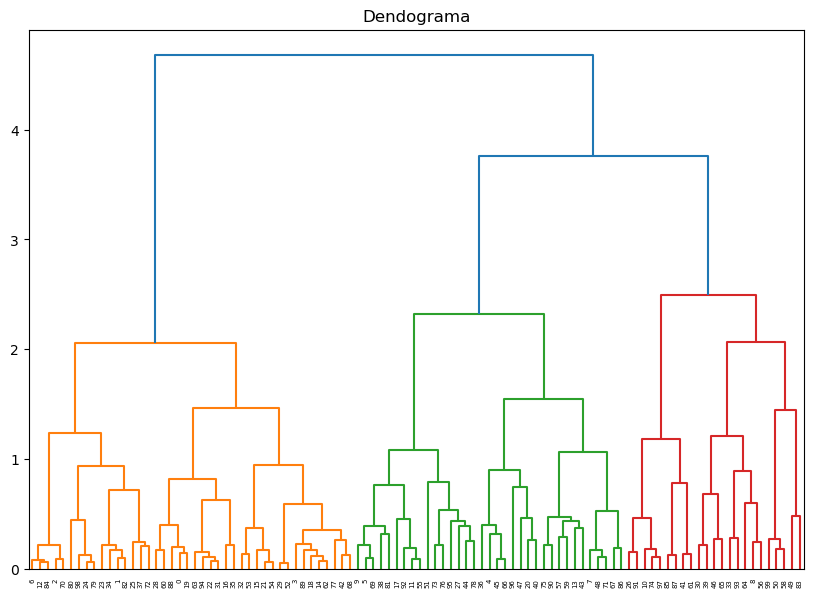

In [33]:
# Vamos a crear el cluster
import scipy.cluster.hierarchy as shc
plt.figure(figsize = (10,7))
plt.title("Dendograma")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

In [35]:
# Obtenemos el número optimo de clusters
colores_unicos = set(dend['color_list'])
num_clusters_optimo = len(colores_unicos) - 1
num_clusters_optimo

3

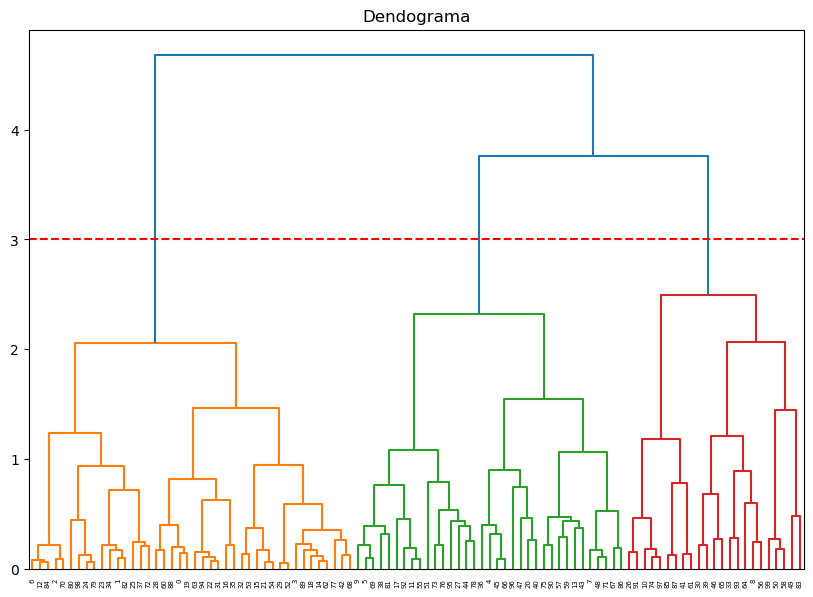

In [127]:
plt.figure(figsize = (10,7))
plt.title("Dendograma")
dend = shc.dendrogram(shc.linkage(data_scaled, method = 'ward'))
plt.axhline(y = 3, color = 'r', linestyle = '--')

In [39]:
# Anlisis grafico con PCA
campos = data_scaled
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2)
pca.fit(campos)
campos = pca.transform(campos)
campos

array([[ 0.39993219, -0.06035374],
       [ 0.40829583,  0.06402268],
       [ 0.49703182,  0.35955286],
       [ 0.33996675, -0.18434501],
       [-0.58207751,  0.38797653],
       [-0.1723403 ,  0.52962573],
       [ 0.56528441,  0.33770585],
       [-0.5335887 , -0.06994712],
       [-0.09981604, -0.47165743],
       [-0.22195207,  0.56503313],
       [-0.08274005, -0.39712712],
       [ 0.00143465,  0.48936583],
       [ 0.57292039,  0.35927774],
       [-0.51350639, -0.01301312],
       [ 0.35272162, -0.20639728],
       [ 0.4688626 , -0.0168001 ],
       [ 0.25142488, -0.04599019],
       [ 0.05456876,  0.22302796],
       [ 0.36123131, -0.20553368],
       [ 0.41087067, -0.02173183],
       [-0.54207892,  0.03308916],
       [ 0.5138909 ,  0.0900875 ],
       [ 0.4284552 ,  0.0601418 ],
       [ 0.42320562,  0.09945498],
       [ 0.42610215, -0.06318626],
       [ 0.10615885,  0.20376697],
       [-0.19058214, -0.3966612 ],
       [ 0.096838  ,  0.33104612],
       [ 0.51505714,

In [41]:
# Obtenemos que elementos pertenecen a cada grupo
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'ward')
grupos = cluster.fit_predict(data_scaled)
grupos

array([1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0], dtype=int64)

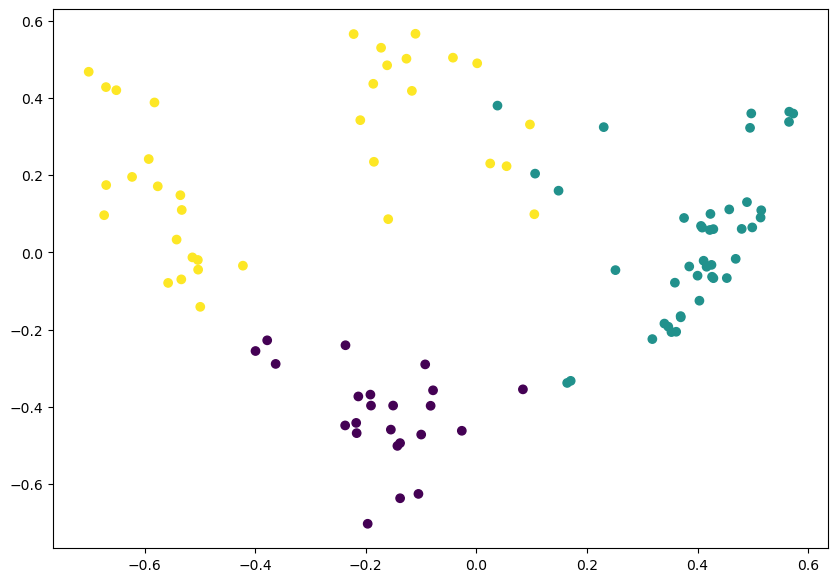

In [43]:
plt.figure(figsize = (10,7))
plt.scatter(campos[:,0], campos[:,1], c = cluster.labels_)

In [45]:
# Creamos un DF para la columna "grupo"
dataframe = pd.DataFrame(grupos, columns = ['grupo'])
dataframe

,grupo
0,1
1,1
2,1
3,1
4,2
...,...
95,2
96,2
97,0
98,1


In [47]:
# Insertamos el df con los datos del grupo en el df original
dataframe2 = pd.concat([data, dataframe], axis = 1, join = 'inner')
dataframe2

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
0,205,3,345,235,24,23,26,21,17,1
1,9,15,315,33,25,4,42,215,28,1
2,17,26,285,3,43,27,41,26,33,1
3,135,5,355,295,18,23,39,195,17,1
4,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...
95,3,8,32,25,7,21,42,17,1,2
96,305,25,46,24,33,28,355,26,45,2
97,1,14,26,25,24,27,42,185,23,0
98,155,11,335,34,26,29,42,215,27,1


In [69]:
# Agregamos los nombres de los clientes
dataframe2.index = nombres
dataframe2

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Adam,205,3,345,235,24,23,26,21,17,1
Anna,9,15,315,33,25,4,42,215,28,1
Bernard,17,26,285,3,43,27,41,26,33,1
Edward,135,5,355,295,18,23,39,195,17,1
Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...
Teofan,3,8,32,25,7,21,42,17,1,2
Teofil,305,25,46,24,33,28,355,26,45,2
Teofila,1,14,26,25,24,27,42,185,23,0
Teon,155,11,335,34,26,29,42,215,27,1


In [133]:
# Buscamos a los clientes especificos para poder trabajar con su grupo
#Buscamos a Lydia
Salome = dataframe2.loc['Salome']
print(Salome)
print('----------------------------------')

#Buscamos a Lydia
Stephania = dataframe2.loc['Stephania']
print(Stephania)
print('----------------------------------')

#Buscamos a Lydia
Lydia = dataframe2.loc['Lydia']
print(Lydia)

Velocidad Entrega     17
Precio                23
Durabilidad          275
Imagen Producto       41
Valor Educativo        4
Servicio Retorno      44
Tamano Paquete       315
Calidad Producto      28
Numero Estrellas      32
grupo                  2
Name: Salome, dtype: int64
----------------------------------
Velocidad Entrega    215
Precio               125
Durabilidad          465
Imagen Producto      315
Valor Educativo       34
Servicio Retorno       4
Tamano Paquete        37
Calidad Producto     305
Numero Estrellas      45
grupo                  1
Name: Stephania, dtype: int64
----------------------------------
Velocidad Entrega     19
Precio                 4
Durabilidad          435
Imagen Producto      145
Valor Educativo       16
Servicio Retorno      21
Tamano Paquete        28
Calidad Producto     185
Numero Estrellas      24
grupo                  1
Name: Lydia, dtype: int64


In [123]:
# Buscamos a los demás clientes pertenecientes a cada grupo
# Para Salomé (Grupo 2)
grupo2 = dataframe2[dataframe2['grupo'] == 2].index.tolist()
print(f"Clientes similares a Salomé: {grupo2}")
print('-------------------------------------------------------------------------------------------------------------------------------------------')
print()
# Para Stephanía y Lydia (Grupo 1)
grupo1 = dataframe2[dataframe2['grupo'] == 1].index.tolist()
print(f"Clientes similares a Stephanía/Lydia: {grupo1}")

Clientes similares a Salomé: ['Emilia', 'Fabian', 'Frank', 'Gabriel', 'Henry', 'Isabelle', 'Eugenia', 'Evdokia', 'Florence', 'Jeremiah', 'Joachim', 'Santiago', 'Justin', 'Kalyna', 'Larissa', 'Leon', 'Leonard', 'Leo', 'Magdalyna', 'Marcel', 'Maria', 'Maryna', 'Matthew', 'Maya', 'Melania', 'Michael', 'Mina', 'Monica', 'Myron', 'Salome', 'Sebastian', 'Susanna', 'Sylvester', 'Teofan', 'Teofil']
-------------------------------------------------------------------------------------------------------------------------------------------

Clientes similares a Stephanía/Lydia: ['Adam', 'Anna', 'Bernard', 'Edward', 'Philip', 'Irene', 'Isidore', 'Joseph', 'Eugene', 'Eunice', 'Eva', 'Fedir', 'Felix', 'Fialka', 'Flavia', 'Flora', 'Hannah', 'Helen', 'Hilary', 'Lourdes', 'Ivan', 'Jacob', 'Jervis', 'Judith', 'Louise', 'Lubomyr', 'Lydia', 'Marian', 'Markian', 'Marko', 'Maura', 'Maximillian', 'Methodius', 'Mykyta', 'Myroslav', 'Myroslava', 'Samuel', 'Sarah', 'Stephan', 'Stephania', 'Theodore', 'Teon']
